# H-Spot Bangkok — Result Analysis

This notebook explores the outputs of both models:
- **Classification Model** (`train_classification.py`): Probability-based Risk Score (0–100%)
- **Count Model** (`train_count.py`): Expected number of accidents per segment (Negative Binomial)

Both used a **Stratified 80/20 Train/Test split** to preserve the natural 1.6% accident rate.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load model outputs
risk_df  = pd.read_parquet('../../data/processed/results/risk_scores_v2_xgboost.parquet')
count_df = pd.read_parquet('../../data/processed/results/count_predictions.parquet')

# Load original model dataset for context
model_df = pd.read_parquet('../../data/processed/features/model_dataset.parquet')

print(f'Risk scores : {len(risk_df):,} segments')
print(f'Count preds : {len(count_df):,} segments')
print(f'Model dataset: {len(model_df):,} segments')
risk_df.head()

Risk scores : 277,069 segments
Count preds : 277,069 segments
Model dataset: 277,069 segments


,segment_id,risk_score,risk_pct
0,98442,1.0,100.0
1,103898,1.0,100.0
2,103889,1.0,100.0
3,103546,1.0,100.0
4,103715,1.0,100.0


## 1. Risk Score Distribution
How are the risk scores spread across Bangkok? Most roads should be near 0%.

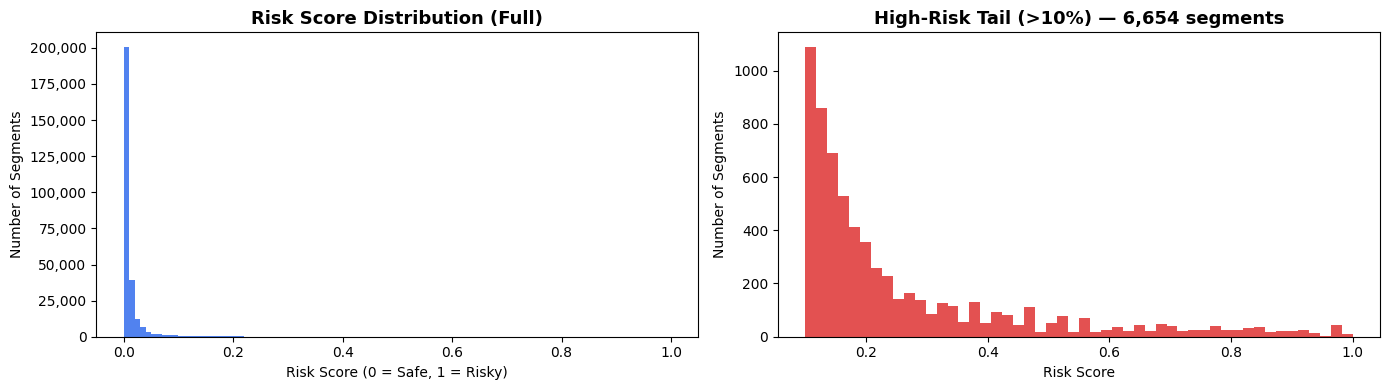

Segments with risk > 10%: 6,654
Segments with risk > 50%: 867
Segments with risk > 80%: 260


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
axes[0].hist(risk_df['risk_score'], bins=100, color='#2563eb', edgecolor='none', alpha=0.8)
axes[0].set_title('Risk Score Distribution (Full)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Score (0 = Safe, 1 = Risky)')
axes[0].set_ylabel('Number of Segments')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Zoom into high-risk tail (>10%)
high = risk_df[risk_df['risk_score'] > 0.10]
axes[1].hist(high['risk_score'], bins=50, color='#dc2626', edgecolor='none', alpha=0.8)
axes[1].set_title(f'High-Risk Tail (>10%) — {len(high):,} segments', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Number of Segments')

plt.tight_layout()
plt.show()

print(f"Segments with risk > 10%: {len(risk_df[risk_df['risk_score'] > 0.10]):,}")
print(f"Segments with risk > 50%: {len(risk_df[risk_df['risk_score'] > 0.50]):,}")
print(f"Segments with risk > 80%: {len(risk_df[risk_df['risk_score'] > 0.80]):,}")

## 2. Top 20 Highest-Risk Segments (Classification Model)
These are the roads XGBoost believes are the most dangerous, based on traffic and road geometry alone.

In [13]:
# Merge risk scores with actual accident counts for validation
top_risk = (
    risk_df.sort_values('risk_score', ascending=False)
    .head(20)
    .merge(model_df[['segment_id', 'acc_total', 'highway_rank', 'lanes',
                      'length_m', 'speed_mean', 'congestion_score']],
           on='segment_id', how='left')
)

print('Top 20 Highest-Risk Segments (Classification Model):')
print(top_risk[['segment_id', 'risk_pct', 'acc_total',
                'highway_rank', 'lanes', 'length_m', 'congestion_score']]
      .rename(columns={'risk_pct': 'risk_%', 'acc_total': 'actual_acc'})
      .to_string(index=False))

Top 20 Highest-Risk Segments (Classification Model):
 segment_id  risk_%  actual_acc  highway_rank  lanes  length_m  congestion_score
      98442   100.0           8             6      4    100.00          4.437222
      98316   100.0           9             6      4    100.00          1.551111
     103887   100.0           5             6      4    100.00         20.420000
      99774   100.0           1             6      4    100.00          1.187222
     102187   100.0           1             6      4    100.00          4.012222
     103713   100.0          16             6      4    100.00          1.878333
     103898   100.0           8             6      6    100.00         13.690000
     103714   100.0          19             6      4    100.00          1.953333
     103715   100.0          14             6      4    100.00          1.855000
     103546   100.0           5             6      4    100.00          3.992222
     103889   100.0           3             6      4    

## 3. Top 20 Highest Expected Accident Counts (NB Model)
These are the roads where the Negative Binomial model predicts the most accidents will occur.

In [14]:
top_count = (
    count_df.sort_values('expected_acc', ascending=False)
    .head(20)
    .merge(model_df[['segment_id', 'highway_rank', 'lanes',
                      'length_m', 'congestion_score']],
           on='segment_id', how='left')
)

print('Top 20 Segments by Expected Accident Count (NB Model):')
print(top_count[['segment_id', 'expected_acc', 'actual_acc',
                 'highway_rank', 'lanes', 'length_m', 'congestion_score']]
      .to_string(index=False))

Top 20 Segments by Expected Accident Count (NB Model):
 segment_id  expected_acc  actual_acc  highway_rank  lanes  length_m  congestion_score
     103470        15.642           1             6      8    100.00          2.203889
       5511        14.450           0             1      3    100.00         50.763333
     259240        10.765           0             1      3    100.00         50.763333
     103471        10.386           3             6      8     48.67          2.617778
     270607         9.869           0             1      3    100.00         50.763333
      27181         6.763           0             1      3     95.18         50.763333
      98162         4.608           9             6      6    100.00          1.160556
     271756         4.490           0             6      6    100.00          1.055556
      84904         4.390           0             5      8     87.84          9.472778
     103747         4.131           0             6      6    100.00       

## 4. Model Agreement — Do Both Models Agree?
Merge both results and check if the top-ranked segments by Risk Score also have high Expected Counts.
High agreement = models are consistent and trustworthy.

In [15]:
# Rank each segment by each model
risk_ranked  = risk_df[['segment_id', 'risk_score']].copy()
risk_ranked['risk_rank'] = risk_ranked['risk_score'].rank(ascending=False).astype(int)

count_ranked = count_df[['segment_id', 'expected_acc']].copy()
count_ranked['count_rank'] = count_ranked['expected_acc'].rank(ascending=False).astype(int)

combined = risk_ranked.merge(count_ranked, on='segment_id', how='inner')

# Spearman rank correlation (how much the rankings agree)
spearman = combined[['risk_rank', 'count_rank']].corr(method='spearman').iloc[0, 1]
print(f'Spearman Rank Correlation between models: {spearman:.3f}')
print(f'  (1.0 = perfect agreement, 0.0 = no agreement, -1.0 = opposite)')

# Segments in Top 1% by both models
threshold = int(len(combined) * 0.01)
both_top  = combined[(combined['risk_rank'] <= threshold) & 
                     (combined['count_rank'] <= threshold)]
print(f'\nSegments in Top 1% by BOTH models: {len(both_top):,}')
print('These are your most confident Black Spots:')
print(both_top.merge(model_df[['segment_id', 'acc_total']], on='segment_id')
      .sort_values('risk_rank')
      .to_string(index=False))

Spearman Rank Correlation between models: 0.398
  (1.0 = perfect agreement, 0.0 = no agreement, -1.0 = opposite)

Segments in Top 1% by BOTH models: 1,433
These are your most confident Black Spots:
 segment_id  risk_score  risk_rank  expected_acc  count_rank  acc_total
      98442    1.000000          6         0.774        1738          8
     103887    1.000000          6         1.270         649          5
      99774    1.000000          6         2.557          50          1
     103713    1.000000          6         0.987        1120         16
      98316    1.000000          6         0.984        1131          9
     103714    1.000000          6         1.072         957         19
     102187    1.000000          6         0.967        1173          1
     103715    1.000000          6         1.103         902         14
     103546    1.000000          6         1.459         449          5
     103889    1.000000          6         0.917        1266          3
     10389

## 5. Validation — Did the Model Find Real Accident Spots?
Top-K Capture Rate: Of all the actual accidents in Bangkok, what % does the model capture in its Top K% predictions?

In [16]:
# Merge risk scores with actual accident data
validation = risk_df.merge(
    model_df[['segment_id', 'acc_total', 'is_risky']], on='segment_id', how='inner'
).sort_values('risk_score', ascending=False)

total_accidents = validation['acc_total'].sum()
total_segments  = len(validation)

print(f'Total accidents in Bangkok: {int(total_accidents):,}')
print(f'Total segments evaluated : {total_segments:,}')
print()
print(f'{"Top-K%":<10} {"Segments":<12} {"Accidents Captured":<22} {"Capture Rate"}')
print('-' * 60)

capture_rates = []
for k in [1, 2, 5, 10, 20]:
    n   = int(total_segments * k / 100)
    top = validation.head(n)
    captured = top['acc_total'].sum()
    rate = captured / total_accidents * 100
    capture_rates.append((k, n, captured, rate))
    print(f'Top {k}%{"":<6} {n:<12,} {int(captured):<22,} {rate:.1f}%')

print()
print('Interpretation: If Top 5% captures >40% of accidents → model is useful.')

Total accidents in Bangkok: 12,260
Total segments evaluated : 277,069

Top-K%     Segments     Accidents Captured     Capture Rate
------------------------------------------------------------
Top 1%       2,770        5,171                  42.2%
Top 2%       5,541        6,567                  53.6%
Top 5%       13,853       8,384                  68.4%
Top 10%       27,706       9,975                  81.4%
Top 20%       55,413       11,284                 92.0%

Interpretation: If Top 5% captures >40% of accidents → model is useful.


## 6. Risk Score by Road Type
Which road types (highway_rank) are associated with the highest predicted risk?

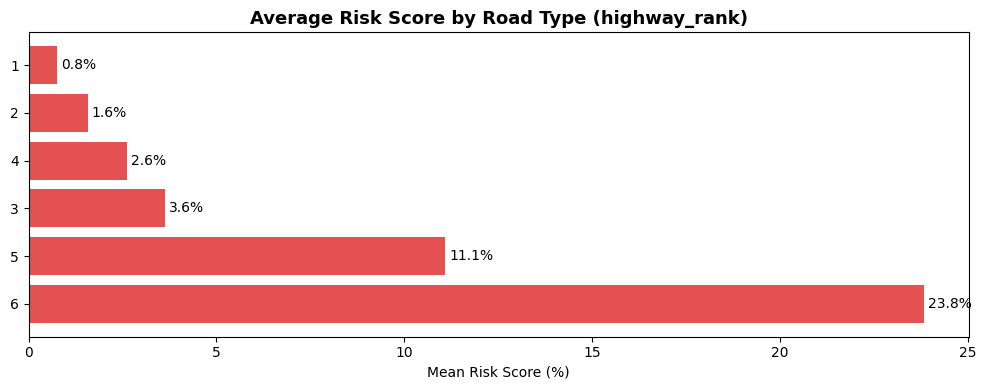

              segments  mean_risk_pct  total_acc
highway_rank                                    
6                 4506          23.84       3705
5                 5233          11.09       1623
3                15592           3.63       1183
4                12580           2.61        679
2                12057           1.57        555
1               227101           0.75       4515


In [17]:
merged = risk_df.merge(
    model_df[['segment_id', 'highway_rank', 'acc_total', 'lanes']], 
    on='segment_id', how='inner'
)

by_road = merged.groupby('highway_rank').agg(
    segments      = ('segment_id', 'count'),
    mean_risk_pct = ('risk_pct', 'mean'),
    total_acc     = ('acc_total', 'sum'),
).round(2).sort_values('mean_risk_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(by_road.index.astype(str), by_road['mean_risk_pct'], color='#dc2626', alpha=0.8)
ax.set_xlabel('Mean Risk Score (%)')
ax.set_title('Average Risk Score by Road Type (highway_rank)', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

print(by_road)